In [17]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import optuna
import joblib
import matplotlib.pyplot as plt
import shap
import os
from sklearn.feature_selection import VarianceThreshold

In [18]:
train_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\data\\extreme_outliers\\train_capped_extreme_outliers.csv"
val_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\data\\extreme_outliers\\val_capped_extreme_outliers.csv"
test_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\data\\extreme_outliers\test_capped_extreme_outliers.csv"
output_params_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\benchmarked_model\\optimized_catboost_params.csv"
output_model_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\models\\catboost_optimized_model.pkl"
results_path = r"D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\benchmarked_model\\catboost_optimized_results.csv"
os.makedirs('reports/benchmarked_model', exist_ok=True)


In [19]:
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print(f"Loaded train data with shape: {df_train.shape}")
print(f"Loaded val data with shape: {df_val.shape}")
print(f"Loaded test data with shape: {df_test.shape}")

Loaded train data with shape: (761, 24)
Loaded val data with shape: (189, 24)
Loaded test data with shape: (329, 24)


In [20]:
X_train = df_train.drop(['log_H2_W% (max)', 'Composition'], axis=1)
y_train = df_train['log_H2_W% (max)']
y_train_original = np.expm1(y_train)
X_val = df_val.drop(['log_H2_W% (max)', 'Composition'], axis=1)
y_val = df_val['log_H2_W% (max)']
y_val_original = np.expm1(y_val)
X_test = df_test.drop(['log_H2_W% (max)', 'Composition'], axis=1)
y_test = df_test['log_H2_W% (max)']
y_test_original = np.expm1(y_test)

In [21]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns).reset_index(drop=True)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns).reset_index(drop=True)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns).reset_index(drop=True)

In [22]:
# X_train_scaled = normalize(X_train_scaled)
# X_val_scaled = normalize(X_val_scaled)
# X_test_scaled = normalize(X_test_scaled)

In [23]:
# selector = VarianceThreshold(threshold=0.3)
# X_train_scaled_array = selector.fit_transform(X_train_scaled)
# X_val_scaled_array = selector.transform(X_val_scaled)
# X_test_scaled_array = selector.transform(X_test_scaled)

# selected_features = X_train_scaled.columns[selector.get_support()].tolist()
# X_train = pd.DataFrame(X_train_scaled_array, columns=selected_features).reset_index(drop=True)
# X_val = pd.DataFrame(X_val_scaled_array, columns=selected_features).reset_index(drop=True)
# X_test = pd.DataFrame(X_test_scaled_array, columns=selected_features).reset_index(drop=True)

# corr_matrix = X_train.corr().abs()
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
# X_train = X_train.drop(columns=to_drop).reset_index(drop=True)
# X_val = X_val.drop(columns=to_drop).reset_index(drop=True)
# X_test = X_test.drop(columns=to_drop).reset_index(drop=True)

# print("\nShape after preprocessing: ")
# print("Trainset shape:", X_train.shape)
# print("Validationset shape:", X_val.shape)
# print("Testset shape:", X_test.shape)

In [24]:
# def optimize_ridge(X, y):
#     def objective(trial):
#         alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
#         model = Ridge(alpha=alpha)
#         model.fit(X, y)
#         y_pred = model.predict(X)
#         return r2_score(y, y_pred)  
    
#     study = optuna.create_study(direction='maximize') 
#     study.optimize(objective, n_trials=50)
#     return study.best_params['alpha']

# best_alpha = optimize_ridge(X_train_scaled, y_train)
# ridge_model = Ridge(alpha=best_alpha)
# ridge_model.fit(X_train_scaled, y_train)
# baseline_train = ridge_model.predict(X_train_scaled)
# baseline_val = ridge_model.predict(X_val_scaled)
# baseline_test = ridge_model.predict(X_test_scaled)
# print(f"Best alpha for Ridge: {best_alpha}")

In [25]:
def evaluate_model(y_true, y_pred, y_original, is_log=True):
    if is_log:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, mse, r2

In [26]:
# mae_ridge_train, mse_ridge_train, r2_ridge_train = evaluate_model(y_train, baseline_train, y_train_original)
# mae_ridge_val, mse_ridge_val, r2_ridge_val= evaluate_model(y_val, baseline_val, y_val_original)
# mae_ridge_test, mse_ridge_test, r2_ridge_test= evaluate_model(y_test, baseline_test, y_test_original)

# print(f"Best alpha is {best_alpha}")
# print(f"Ridge (Optimized): R² Train: {r2_ridge_train:.4f}, R² Val: {r2_ridge_val:.4f}, R² Test: {r2_ridge_test:.4f}")

In [ ]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.1, 0.25),
        'depth': trial.suggest_int('depth', 6, 10),
        'iterations': trial.suggest_int('iterations', 300, 900),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3, 10),
        # 'bagging_temperature': trial.suggest_float('bagging_temperature', 0.5, 1.0),
        'random_strength': trial.suggest_float('random_strength', 5, 20),
        # 'early_stopping_rounds': trial.suggest_int('early_stopping_rounds', 100, 200),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0
    }
    model = CatBoostRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2', n_jobs=-1)
    if cv_scores.mean() < 0:
        print(f"Warning: Negative R² detected in trial {trial.number}: {cv_scores.mean():.4f}")
    return cv_scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
best_score = study.best_value

print(f"Best parameters: {best_params}")
print(f"Best Cross-Validation R²: {best_score:.4f}")

[I 2025-07-05 03:16:52,333] A new study created in memory with name: no-name-cbd7b60b-a80b-4a91-b5cf-a2f96697b1e5
[I 2025-07-05 03:16:55,344] Trial 0 finished with value: 0.6928577714337811 and parameters: {'learning_rate': 0.1497214886738483, 'depth': 6, 'iterations': 505, 'l2_leaf_reg': 3.417873069562084, 'random_strength': 8.69637613171244, 'early_stopping_rounds': 136}. Best is trial 0 with value: 0.6928577714337811.
[I 2025-07-05 03:16:59,210] Trial 1 finished with value: 0.7014439314747744 and parameters: {'learning_rate': 0.11711873500111403, 'depth': 6, 'iterations': 728, 'l2_leaf_reg': 4.789092995292313, 'random_strength': 16.25878332371243, 'early_stopping_rounds': 114}. Best is trial 1 with value: 0.7014439314747744.
[I 2025-07-05 03:17:32,437] Trial 2 finished with value: 0.6898818008900013 and parameters: {'learning_rate': 0.2006718416935795, 'depth': 9, 'iterations': 544, 'l2_leaf_reg': 7.328830450908029, 'random_strength': 19.605887012859235, 'early_stopping_rounds': 189

Best parameters: {'learning_rate': 0.24957356422915006, 'depth': 7, 'iterations': 301, 'l2_leaf_reg': 9.909126672898484, 'random_strength': 5.1183653194448935, 'early_stopping_rounds': 199}
Best Cross-Validation R²: 0.7154


In [ ]:
# Train Model with Optimized Hyperparameters
best_model = CatBoostRegressor(**best_params, random_seed=42, verbose=0)
best_model.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), early_stopping_rounds=200, verbose=0)

In [29]:
importance_threshold = 2.0
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.get_feature_importance()
})
selected_features = feature_importance[feature_importance['importance'] > importance_threshold]['feature'].tolist()
X_train_selected = X_train_scaled[selected_features]
X_val_selected = X_val_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

In [30]:
X_train_selected

,temperature(K),MagpieData mean Column,VEC mean,MagpieData mean Number,MagpieData mode CovalentRadius,MagpieData mean MendeleevNumber,Mixing enthalpy,Mean cohesive energy,MagpieData mode Number,MagpieData mean NsValence,...,MagpieData avg_dev AtomicWeight,MagpieData mean CovalentRadius,MagpieData range Electronegativity,MagpieData mean SpaceGroupNumber,MagpieData avg_dev NValence,Shear modulus local mismatch,Miedema_deltaH_ss_min,MagpieData avg_dev MendeleevNumber,Shear modulus mean,MagpieData mean GSvolume_pa
0,2.097764,-2.440070,-2.225264,-1.912434,0.222607,2.408220,-1.042949,-2.679884,-1.413402,0.451306,...,-1.116918,-0.615162,0.270879,-1.811988,-1.564245,-1.974633,1.036757,-1.270256,-2.428910,2.345664
1,2.317893,-1.904692,-1.720942,-1.691131,0.222607,2.286459,-0.906206,-2.336923,-1.413402,0.451306,...,-0.596656,-0.857096,0.270879,-1.440212,0.006735,-0.814131,1.173394,-0.999239,-2.010456,1.863774
2,2.384889,-1.850925,-1.670294,-1.682856,0.222607,2.342210,-0.944009,-2.457866,-1.413402,0.121653,...,-0.533623,-0.736068,0.229243,-1.449745,0.171337,-1.451887,1.018263,-1.123362,-2.240065,1.905129
3,2.097764,-1.473414,-1.314682,-1.299358,0.222607,1.850409,-0.685501,-1.951663,-1.413402,0.451306,...,0.193156,-0.703956,1.145231,-1.157408,0.903494,-0.119816,0.910323,-0.211506,-1.698525,1.689977
4,2.097764,-1.809093,-1.630888,-1.344415,0.222607,1.704747,-0.171369,-1.787697,-1.413402,0.303093,...,0.093068,-0.387240,-0.062207,-1.189060,-0.027763,0.328907,1.468637,0.039971,-1.530083,1.673099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
756,-0.534219,-1.085608,-0.949372,1.342802,1.085078,-1.007038,-1.034913,1.884409,-0.310337,-0.107428,...,1.429035,2.361023,-0.853288,-0.389665,2.517863,-1.285847,1.234454,-1.053891,-0.910437,0.974490
757,2.088193,-1.085608,-0.949372,1.342802,1.085078,-1.007038,-1.034913,1.884409,-0.310337,-0.107428,...,1.429035,2.361023,-0.853288,-0.389665,2.517863,-1.285847,1.234454,-1.053891,-0.910437,0.974490
758,-0.582074,-0.969667,-0.840157,1.794073,1.156950,-0.886824,-0.902857,2.186270,-0.310337,-0.666999,...,1.148977,2.383551,1.853039,-0.388794,2.451828,0.791024,0.885479,-0.870617,-0.051022,1.149434
759,-0.582074,-0.969667,-0.840157,1.792182,1.156950,-0.886898,-0.904692,2.185295,-0.310337,-0.668395,...,1.143741,2.383733,1.519953,-0.388794,2.441097,0.790513,0.892798,-0.870730,-0.051329,1.149334


In [ ]:
best_model.fit(X_train_selected, y_train, eval_set=(X_val_selected, y_val), early_stopping_rounds=200, verbose=0)

In [32]:
y_train_pred_log = best_model.predict(X_train_selected)
train_mse_log = mean_squared_error(y_train, y_train_pred_log)
train_mae_log = mean_absolute_error(y_train, y_train_pred_log)
train_r2_log = r2_score(y_train, y_train_pred_log)

y_val_pred_log = best_model.predict(X_val_selected)
val_mse_log = mean_squared_error(y_val, y_val_pred_log)
val_mae_log = mean_absolute_error(y_val, y_val_pred_log)
val_r2_log = r2_score(y_val, y_val_pred_log)

y_test_pred_log = best_model.predict(X_test_selected)
test_mse_log = mean_squared_error(y_test, y_test_pred_log)
test_mae_log = mean_absolute_error(y_test, y_test_pred_log)
test_r2_log = r2_score(y_test, y_test_pred_log)

y_train_orig = np.expm1(y_train)
y_train_pred_orig = np.expm1(y_train_pred_log)
train_mse_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
train_mae_orig = mean_absolute_error(y_train_orig, y_train_pred_orig)
train_r2_orig = r2_score(y_train_orig, y_train_pred_orig)

y_val_orig = np.expm1(y_val)
y_val_pred_orig = np.expm1(y_val_pred_log)
val_mse_orig = mean_squared_error(y_val_orig, y_val_pred_orig)
val_mae_orig = mean_absolute_error(y_val_orig, y_val_pred_orig)
val_r2_orig = r2_score(y_val_orig, y_val_pred_orig)

y_test_orig = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred_log)
test_mse_orig = mean_squared_error(y_test_orig, y_test_pred_orig)
test_mae_orig = mean_absolute_error(y_test_orig, y_test_pred_orig)
test_r2_orig = r2_score(y_test_orig, y_test_pred_orig)

print(f"Train (log scale) - MSE: {train_mse_log:.4f}, MAE: {train_mae_log:.4f}, R²: {train_r2_log:.4f}")
print(f"Validation (log scale) - MSE: {val_mse_log:.4f}, MAE: {val_mae_log:.4f}, R²: {val_r2_log:.4f}")
print(f"Test (log scale) - MSE: {test_mse_log:.4f}, MAE: {test_mae_log:.4f}, R²: {test_r2_log:.4f}")
print(f"Train (original scale) - MSE: {train_mse_orig:.4f}, MAE: {train_mae_orig:.4f}, R²: {train_r2_orig:.4f}")
print(f"Validation (original scale) - MSE: {val_mse_orig:.4f}, MAE: {val_mae_orig:.4f}, R²: {val_r2_orig:.4f}")
print(f"Test (original scale) - MSE: {test_mse_orig:.4f}, MAE: {test_mae_orig:.4f}, R²: {test_r2_orig:.4f}")

Train (log scale) - MSE: 0.0020, MAE: 0.0320, R²: 0.9795
Validation (log scale) - MSE: 0.0202, MAE: 0.0934, R²: 0.7729
Test (log scale) - MSE: 0.0338, MAE: 0.1240, R²: 0.7047
Train (original scale) - MSE: 0.0167, MAE: 0.0912, R²: 0.9804
Validation (original scale) - MSE: 0.2191, MAE: 0.2815, R²: 0.7570
Test (original scale) - MSE: 0.3485, MAE: 0.3700, R²: 0.6944


array([[ 0.00217617,  0.01935648,  0.05085377, ..., -0.04670373,
        -0.00395353,  0.00265918],
       [ 0.01606965,  0.02976399,  0.03788389, ..., -0.00439441,
         0.00116937,  0.00714401],
       [ 0.01805401, -0.00246195,  0.0376509 , ..., -0.00184891,
        -0.00325022,  0.02064018],
       ...,
       [-0.00241267,  0.02822922,  0.04219065, ...,  0.00171382,
         0.00590791, -0.00043609],
       [ 0.05047861,  0.02805867,  0.03990233, ...,  0.010023  ,
        -0.00041032,  0.00911115],
       [ 0.05701976,  0.04144033, -0.00089416, ...,  0.0009648 ,
         0.00389505,  0.0133189 ]])

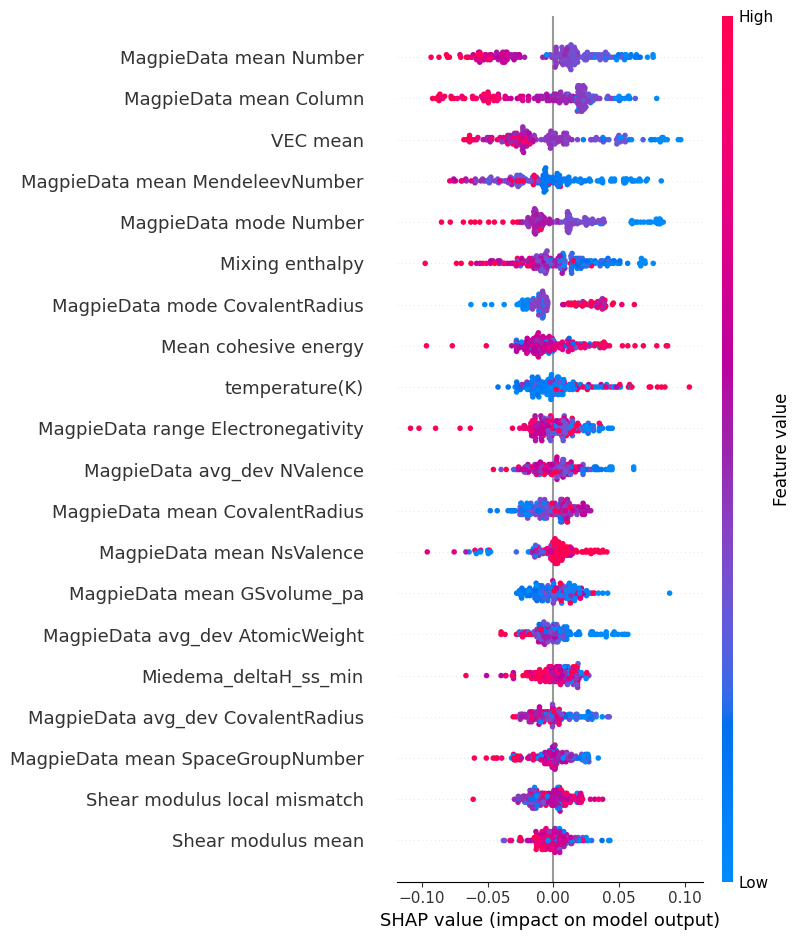

<Figure size 640x480 with 0 Axes>

In [33]:
# SHAP Analysis
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_selected)
shap.summary_plot(shap_values, X_val_selected, feature_names=selected_features)
plt.savefig(os.path.join(os.path.dirname(results_path), 'shap_summary_plot_no_pool.png'))
plt.show()

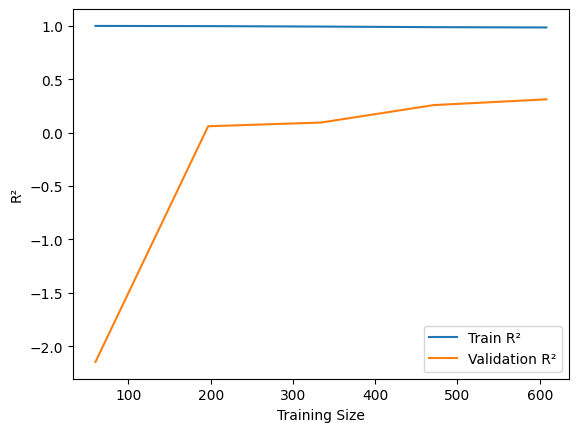

In [34]:
# Learning Curves
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_selected, y_train, cv=5, scoring='r2', n_jobs=-1
)
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train R²')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation R²')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.savefig(os.path.join(os.path.dirname(results_path), 'catboost_learning_curve_no_pool.png'))
plt.show()

In [35]:
results_df = pd.DataFrame({
    'Cross-Validation R² (log scale)': [best_score],
    'Train R² (log scale)': [train_r2_log],
    'Train MSE (log scale)': [train_mse_log],
    'Train MAE (log scale)': [train_mae_log],
    'Validation R² (log scale)': [val_r2_log],
    'Validation MSE (log scale)': [val_mse_log],
    'Validation MAE (log scale)': [val_mae_log],
    'Test R² (log scale)': [test_r2_log],
    'Test MSE (log scale)': [test_mse_log],
    'Test MAE (log scale)': [test_mae_log],
    'Train R² (original scale)': [train_r2_orig],
    'Train MSE (original scale)': [train_mse_orig],
    'Train MAE (original scale)': [train_mae_orig],
    'Validation R² (original scale)': [val_r2_orig],
    'Validation MSE (original scale)': [val_mse_orig],
    'Validation MAE (original scale)': [val_mae_orig],
    'Test R² (original scale)': [test_r2_orig],
    'Test MSE (original scale)': [test_mse_orig],
    'Test MAE (original scale)': [test_mae_orig],
    'Feature Importance': [dict(zip(selected_features, best_model.get_feature_importance()))]
})
results_df.to_csv(results_path, index=False)
print(f"Model results saved to {results_path}")

Model results saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\benchmarked_model\\catboost_optimized_results.csv


In [36]:
results_df

,Cross-Validation R² (log scale),Train R² (log scale),Train MSE (log scale),Train MAE (log scale),Validation R² (log scale),Validation MSE (log scale),Validation MAE (log scale),Test R² (log scale),Test MSE (log scale),Test MAE (log scale),Train R² (original scale),Train MSE (original scale),Train MAE (original scale),Validation R² (original scale),Validation MSE (original scale),Validation MAE (original scale),Test R² (original scale),Test MSE (original scale),Test MAE (original scale),Feature Importance
0,0.715434,0.979452,0.001977,0.032032,0.772864,0.020248,0.093441,0.704692,0.033809,0.123978,0.980369,0.016681,0.091243,0.756959,0.219064,0.281465,0.694383,0.348454,0.369987,"{'temperature(K)': 4.437938842229868, 'MagpieD..."


In [37]:
# Save Model
joblib.dump(best_model, output_model_path)
print(f"Model saved to {output_model_path}")

# Save Optimized Parameter
best_params_df = pd.DataFrame([best_params | {'best_r2': best_score}])
best_params_df.to_csv(output_params_path, index=False)
print(f"Optimized parameters saved to {output_params_path}")

Model saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\models\\catboost_optimized_model.pkl
Optimized parameters saved to D:\\Hydride_Machine_learning_project\\Machine_Model\\reports\\benchmarked_model\\optimized_catboost_params.csv
